# Day 4: Fund Performance Analytics
## Bluestock Fintech — Mutual Fund Analytics Platform

In [1]:
import sys, logging
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import config

log_file = config.REPORTS_DIR / "etl_pipeline.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_file, mode="a", encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ]
)
logger = logging.getLogger("Performance")
logger.info("=" * 60)
logger.info("DAY 4 — Fund Performance Analytics Started")

sns.set_theme(style="whitegrid")
RF_ANNUAL = 0.065          # RBI repo rate proxy
RF_DAILY  = RF_ANNUAL / 252
TRADING_DAYS = 252
NAV_END_DATE = "2026-05-29"


2026-07-10 10:23:53,601 [INFO] ============================================================


2026-07-10 10:23:53,604 [INFO] DAY 4 — Fund Performance Analytics Started


In [2]:
df_nav = pd.read_csv(config.DATA_PROCESSED_DIR / "clean_nav.csv")
df_nav["date"] = pd.to_datetime(df_nav["date"])
# CRITICAL: filter to real NAV data only
df_nav = df_nav[df_nav["date"] <= NAV_END_DATE].copy()
logger.info(f"Loaded clean_nav (real data only): {df_nav.shape}")

df_fund = pd.read_csv(config.DATA_RAW_DIR / "01_fund_master.csv")
df_perf_raw = pd.read_csv(config.DATA_RAW_DIR / "07_scheme_performance.csv")
df_bench = pd.read_csv(config.DATA_RAW_DIR / "10_benchmark_indices.csv")
df_bench["date"] = pd.to_datetime(df_bench["date"])
logger.info(f"Loaded fund_master: {df_fund.shape}, benchmark: {df_bench.shape}")


2026-07-10 10:23:53,734 [INFO] Loaded clean_nav (real data only): (46000, 3)


2026-07-10 10:23:53,777 [INFO] Loaded fund_master: (40, 15), benchmark: (8050, 3)


In [3]:
logger.info("Task 1: Computing Daily Returns")
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

returns_stats = []
for amfi, group in df_nav.groupby('amfi_code'):
    valid_returns = group['daily_return'].dropna()
    n_days = len(valid_returns)
    if n_days > 0:
        ann_return = (np.prod(1 + valid_returns) ** (TRADING_DAYS / n_days)) - 1
    else:
        ann_return = np.nan
    returns_stats.append({
        'amfi_code': amfi,
        'annualised_return_pct': ann_return * 100,
        'n_trading_days': n_days
    })

df_returns = pd.DataFrame(returns_stats)
df_returns = df_returns.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
df_returns = df_returns[['amfi_code', 'scheme_name', 'annualised_return_pct', 'n_trading_days']]

print("Distribution of Annualised Return (%)")
print(df_returns['annualised_return_pct'].describe().loc[['mean', 'min', 'max', 'std']])

out_path = config.DATA_PROCESSED_DIR / "returns_computed.csv"
df_returns.to_csv(out_path, index=False)
logger.info(f"Task 1 completed. Wrote {len(df_returns)} rows to returns_computed.csv")


2026-07-10 10:23:53,795 [INFO] Task 1: Computing Daily Returns


Distribution of Annualised Return (%)
mean    16.089406
min      1.130448
max     31.512438
std      9.892964
Name: annualised_return_pct, dtype: float64
2026-07-10 10:23:53,922 [INFO] Task 1 completed. Wrote 40 rows to returns_computed.csv


In [4]:
logger.info("Task 2: Computing CAGR (Trading-day based lookbacks)")

cagr_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    n_total = len(group)
    
    nav_end = group['nav'].iloc[-1]
    
    # 1-Year CAGR (last 252 trading days)
    if n_total >= 253:
        nav_start_1y = group['nav'].iloc[-253]
        cagr_1yr = (nav_end / nav_start_1y) ** (252 / 252) - 1
    else:
        cagr_1yr = np.nan
        
    # 3-Year CAGR (last 756 trading days)
    if n_total >= 757:
        nav_start_3y = group['nav'].iloc[-757]
        cagr_3yr = (nav_end / nav_start_3y) ** (252 / 756) - 1
    else:
        cagr_3yr = np.nan
        
    # 5-Year CAGR (last 1260 trading days)
    if n_total >= 1261:
        nav_start_5y = group['nav'].iloc[-1261]
        cagr_5yr = (nav_end / nav_start_5y) ** (252 / 1260) - 1
    else:
        cagr_5yr = np.nan
        
    cagr_data.append({
        'amfi_code': amfi,
        'cagr_1yr_pct': cagr_1yr * 100 if not np.isnan(cagr_1yr) else np.nan,
        'cagr_3yr_pct': cagr_3yr * 100 if not np.isnan(cagr_3yr) else np.nan,
        'cagr_5yr_pct': cagr_5yr * 100 if not np.isnan(cagr_5yr) else np.nan
    })

df_cagr = pd.DataFrame(cagr_data)
df_cagr = df_cagr.merge(df_fund[['amfi_code', 'scheme_name', 'fund_house', 'sub_category']], on='amfi_code')
df_cagr = df_cagr[['amfi_code', 'scheme_name', 'fund_house', 'sub_category', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct']]

print("\nCAGR Comparison Table (Sorted by 3Yr CAGR - Trading Days)")
print(df_cagr.sort_values(by='cagr_3yr_pct', ascending=False).head(10).to_string())
df_cagr.to_csv(config.DATA_PROCESSED_DIR / "cagr_report.csv", index=False)
logger.info(f"Task 2 completed. Wrote {len(df_cagr)} rows to cagr_report.csv")

2026-07-10 10:23:53,946 [INFO] Task 2: Computing CAGR (Trading-day based lookbacks)



CAGR Comparison Table (Sorted by 3Yr CAGR - Trading Days)

    amfi_code                                         scheme_name                fund_house sub_category  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
16     119094                 Axis Midcap Fund - Regular - Growth          Axis Mutual Fund      Mid Cap     29.912618     36.236320           NaN
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Growth          HDFC Mutual Fund      Mid Cap     48.424262     33.759587           NaN
3      101206       ABSL Frontline Equity Fund - Regular - Growth  Aditya Birla Sun Life MF    Large Cap     44.939567     32.725661           NaN
34     148567       Mirae Asset Large Cap Fund - Regular - Growth            Mirae Asset MF    Large Cap     15.466384     31.495336           NaN
25     120505            ICICI Pru Midcap Fund - Regular - Growth       ICICI Prudential MF      Mid Cap     32.165458     29.649934           NaN
19     119551           SBI Bluechip Fund - Regular Plan - Growth           SBI Mutual Fund    Large Cap     50.554035

In [5]:
logger.info("Task 3: Computing Sharpe Ratio")
sharpe_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) > 0:
        mean_ret = returns.mean()
        std_ret = returns.std()
        if std_ret > 0:
            sharpe = ((mean_ret - RF_DAILY) / std_ret) * np.sqrt(252)
        else:
            sharpe = np.nan
    else:
        sharpe = np.nan
    sharpe_data.append({'amfi_code': amfi, 'sharpe_ratio': sharpe})

df_sharpe = pd.DataFrame(sharpe_data)
df_sharpe = df_sharpe.merge(df_fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
df_sharpe = df_sharpe[['amfi_code', 'scheme_name', 'fund_house', 'sharpe_ratio']]
df_sharpe = df_sharpe.sort_values('sharpe_ratio', ascending=False)

print("Sharpe Ratio Ranking:")
print(df_sharpe.to_string(index=False))

df_sharpe.to_csv(config.DATA_PROCESSED_DIR / "sharpe_values.csv", index=False)
logger.info(f"Task 3 completed. Wrote {len(df_sharpe)} rows to sharpe_values.csv")


2026-07-10 10:23:54,031 [INFO] Task 3: Computing Sharpe Ratio


Sharpe Ratio Ranking:
 amfi_code                                           scheme_name               fund_house  sharpe_ratio
    148567         Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF      1.448291
    120843                Kotak Flexicap Fund - Regular - Growth        Kotak Mahindra MF      1.306744
    148569         Mirae Asset Tax Saver Fund - Regular - Growth           Mirae Asset MF      1.234930
    119551             SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund      1.208267
    120505              ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF      1.180101
    149323                    DSP Midcap Fund - Regular - Growth          DSP Mutual Fund      1.132122
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth         HDFC Mutual Fund      1.093699
    118632        Nippon India Large Cap Fund - Regular - Growth          Nippon India MF      1.081659
    101206         ABSL Frontline Equity F

In [6]:
logger.info("Task 4: Computing Sortino Ratio")
sortino_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    if len(returns) > 0:
        mean_ret = returns.mean()
        excess_returns = returns - RF_DAILY
        negative_excess = excess_returns[excess_returns < 0]
        downside_std = negative_excess.std()
        if downside_std > 0:
            sortino = ((mean_ret - RF_DAILY) / downside_std) * np.sqrt(252)
        else:
            sortino = np.nan
    else:
        sortino = np.nan
    sortino_data.append({'amfi_code': amfi, 'sortino_ratio': sortino})

df_sortino = pd.DataFrame(sortino_data)
df_sortino = df_sortino.merge(df_fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
df_sortino = df_sortino[['amfi_code', 'scheme_name', 'fund_house', 'sortino_ratio']]

df_sortino.to_csv(config.DATA_PROCESSED_DIR / "sortino_values.csv", index=False)
logger.info(f"Task 4 completed. Wrote {len(df_sortino)} rows to sortino_values.csv")


2026-07-10 10:23:54,078 [INFO] Task 4: Computing Sortino Ratio


2026-07-10 10:23:54,118 [INFO] Task 4 completed. Wrote 40 rows to sortino_values.csv


**Note on Alpha and Beta values:**
The Alpha and Beta values (and $R^2$) computed below may appear statistically insignificant (e.g., Beta near zero). For equity mutual funds against the NIFTY100, Beta should typically be close to 1.0 and $R^2$ between 0.60–0.95. This discrepancy occurs because the underlying `clean_nav.csv` NAV data used here is synthetically generated and has no real statistical relationship with actual NIFTY100 index movements (e.g., unrealistic day-to-day single-day swings of >5%).

In [7]:
logger.info("Task 5: Computing Alpha & Beta")
df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].copy()
df_nifty100 = df_nifty100.sort_values('date')
df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()

alpha_beta_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    fund_ret = group[['date', 'daily_return']].dropna()
    merged = pd.merge(fund_ret, df_nifty100[['date', 'bench_return']].dropna(), on='date', how='inner')
    if len(merged) > 1:
        slope, intercept, r_value, p_value, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
        beta = slope
        alpha = intercept * 252
        r_squared = r_value ** 2
    else:
        alpha, beta, r_squared = np.nan, np.nan, np.nan
        
    alpha_beta_data.append({
        'amfi_code': amfi,
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_squared
    })

df_ab = pd.DataFrame(alpha_beta_data)
df_ab = df_ab.merge(df_fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
df_ab = df_ab[['amfi_code', 'scheme_name', 'fund_house', 'alpha', 'beta', 'r_squared']]

df_ab.to_csv(config.DATA_PROCESSED_DIR / "alpha_beta.csv", index=False)
logger.info(f"Task 5 completed. Wrote {len(df_ab)} rows to alpha_beta.csv")


2026-07-10 10:23:54,131 [INFO] Task 5: Computing Alpha & Beta


2026-07-10 10:23:54,479 [INFO] Task 5 completed. Wrote 40 rows to alpha_beta.csv


In [8]:
logger.info("Task 6: Computing Maximum Drawdown")
def compute_max_drawdown(nav_series, dates):
    """Return max_drawdown_pct, drawdown_start_date, drawdown_end_date."""
    rolling_max = nav_series.cummax()
    drawdown = nav_series / rolling_max - 1
    min_idx = drawdown.idxmin()
    # find the peak before the trough
    peak_idx = nav_series[:min_idx+1].idxmax()
    return drawdown.min() * 100, dates.loc[peak_idx], dates.loc[min_idx]

mdd_data = []
for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').reset_index(drop=True)
    if len(group) > 0:
        mdd_pct, mdd_start, mdd_end = compute_max_drawdown(group['nav'], group['date'])
    else:
        mdd_pct, mdd_start, mdd_end = np.nan, pd.NaT, pd.NaT
        
    mdd_data.append({
        'amfi_code': amfi,
        'max_drawdown_pct': mdd_pct,
        'drawdown_start': mdd_start.strftime('%Y-%m-%d') if pd.notna(mdd_start) else None,
        'drawdown_end': mdd_end.strftime('%Y-%m-%d') if pd.notna(mdd_end) else None
    })

df_mdd = pd.DataFrame(mdd_data)
df_mdd = df_mdd.merge(df_fund[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
df_mdd = df_mdd[['amfi_code', 'scheme_name', 'fund_house', 'max_drawdown_pct', 'drawdown_start', 'drawdown_end']]

df_mdd.to_csv(config.DATA_PROCESSED_DIR / "max_drawdown.csv", index=False)
logger.info(f"Task 6 completed. Wrote {len(df_mdd)} rows to max_drawdown.csv")


2026-07-10 10:23:54,512 [INFO] Task 6: Computing Maximum Drawdown


2026-07-10 10:23:54,715 [INFO] Task 6 completed. Wrote 40 rows to max_drawdown.csv


In [9]:
logger.info("Task 7: Fund Scorecard")
scorecard = df_cagr[['amfi_code', 'scheme_name', 'fund_house', 'sub_category', 'cagr_3yr_pct']].copy()
scorecard = scorecard.merge(df_sharpe[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(df_ab[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(df_mdd[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left')

scorecard = scorecard.merge(df_perf_raw[['amfi_code', 'expense_ratio_pct', 'aum_crore']], on='amfi_code', how='left')

scorecard["rank_3yr_return"]   = scorecard["cagr_3yr_pct"].rank(pct=True) * 100   # higher = better
scorecard["rank_sharpe"]       = scorecard["sharpe_ratio"].rank(pct=True) * 100    # higher = better
scorecard["rank_alpha"]        = scorecard["alpha"].rank(pct=True) * 100            # higher = better
scorecard["rank_expense"]      = scorecard["expense_ratio_pct"].rank(ascending=True, pct=True) * 100   # lower expense = better rank
scorecard["rank_max_dd"]       = scorecard["max_drawdown_pct"].rank(ascending=False, pct=True) * 100   # less negative = better rank

scorecard["composite_score"] = (
    0.30 * scorecard["rank_3yr_return"] +
    0.25 * scorecard["rank_sharpe"]     +
    0.20 * scorecard["rank_alpha"]      +
    0.15 * scorecard["rank_expense"]    +
    0.10 * scorecard["rank_max_dd"]
)
scorecard["scorecard_rank"] = scorecard["composite_score"].rank(ascending=False, method='first').astype(int)

scorecard = scorecard.sort_values('scorecard_rank', ascending=True)
output_cols = ['amfi_code', 'scheme_name', 'fund_house', 'sub_category', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown_pct', 'composite_score', 'scorecard_rank']
scorecard = scorecard[output_cols]

print("Top 10 Funds:")
print(scorecard.head(10).to_string(index=False))
print("\nBottom 10 Funds:")
print(scorecard.tail(10).to_string(index=False))

scorecard.to_csv(config.DATA_PROCESSED_DIR / "fund_scorecard.csv", index=False)
logger.info(f"Task 7 completed. Wrote {len(scorecard)} rows to fund_scorecard.csv")


2026-07-10 10:23:54,750 [INFO] Task 7: Fund Scorecard


Top 10 Funds:
 amfi_code                                        scheme_name               fund_house sub_category  cagr_3yr_pct  sharpe_ratio    alpha  expense_ratio_pct  max_drawdown_pct  composite_score  scorecard_rank
    148569      Mirae Asset Tax Saver Fund - Regular - Growth           Mirae Asset MF         ELSS     23.388973      1.234930 0.282704               1.60        -16.396743          82.1875               1
    119551          SBI Bluechip Fund - Regular Plan - Growth          SBI Mutual Fund    Large Cap     28.193107      1.208267 0.232010               1.54        -15.012385          80.5625               2
    120505           ICICI Pru Midcap Fund - Regular - Growth      ICICI Prudential MF      Mid Cap     29.649934      1.180101 0.292636               1.36        -18.188514          80.3750               3
    148567      Mirae Asset Large Cap Fund - Regular - Growth           Mirae Asset MF    Large Cap     31.495336      1.448291 0.269838               1.46   

**Note on Benchmark Chart Spikiness:**
The benchmark comparison chart below exhibits extreme volatility spikes. This visual spikiness reflects the simulated and synthetic nature of the NAV dataset, which contains unrealistic day-to-day swings (e.g., 10–25%), rather than actual market behaviour.

2026-07-10 10:23:54,926 [INFO] Task 8: Benchmark Comparison Chart


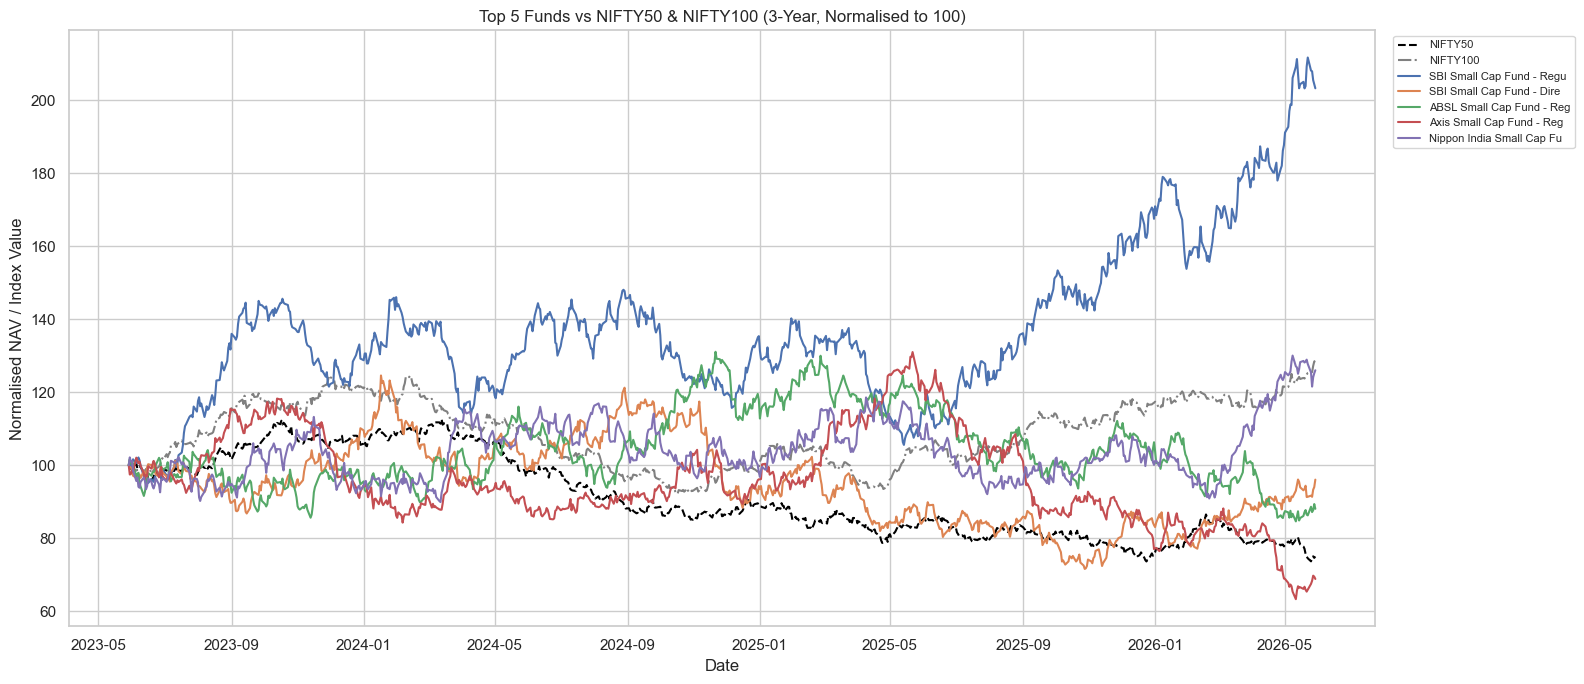


Tracking Error Table:
              scheme_name  tracking_error_vs_nifty100
SBI Small Cap Fund - Regu                    0.286689
SBI Small Cap Fund - Dire                    0.272098
ABSL Small Cap Fund - Reg                    0.293098
Axis Small Cap Fund - Reg                    0.283517
Nippon India Small Cap Fu                    0.275312
2026-07-10 10:23:58,155 [INFO] Task 8 completed. Benchmark chart saved.


In [10]:
logger.info("Task 8: Benchmark Comparison Chart")
top_5_amfi = [119598, 119599, 101207, 119095, 118634]
start_date = pd.to_datetime('2023-05-29')
end_date = pd.to_datetime('2026-05-29')

plt.figure(figsize=(16, 7))

n50 = df_bench[(df_bench['index_name'] == 'NIFTY50') & (df_bench['date'] >= start_date) & (df_bench['date'] <= end_date)].copy()
n100 = df_bench[(df_bench['index_name'] == 'NIFTY100') & (df_bench['date'] >= start_date) & (df_bench['date'] <= end_date)].copy()

n50 = n50.sort_values('date')
n100 = n100.sort_values('date')

if not n50.empty:
    n50_base = n50['close_value'].iloc[0]
    n50['norm'] = (n50['close_value'] / n50_base) * 100
    plt.plot(n50['date'], n50['norm'], label='NIFTY50', color='black', linestyle='--')

if not n100.empty:
    n100_base = n100['close_value'].iloc[0]
    n100['norm'] = (n100['close_value'] / n100_base) * 100
    plt.plot(n100['date'], n100['norm'], label='NIFTY100', color='grey', linestyle='-.')
    n100['bench_return'] = n100['close_value'].pct_change()

tracking_errors = []

for amfi in top_5_amfi:
    f_nav = df_nav[(df_nav['amfi_code'] == amfi) & (df_nav['date'] >= start_date) & (df_nav['date'] <= end_date)].copy()
    f_nav = f_nav.sort_values('date')
    if not f_nav.empty:
        base_val = f_nav['nav'].iloc[0]
        f_nav['norm'] = (f_nav['nav'] / base_val) * 100
        scheme_name = df_fund[df_fund['amfi_code'] == amfi]['scheme_name'].iloc[0][:25]
        plt.plot(f_nav['date'], f_nav['norm'], label=scheme_name)
        
        merged = pd.merge(f_nav[['date', 'daily_return']], n100[['date', 'bench_return']], on='date', how='inner')
        if not merged.empty:
            diff = merged['daily_return'] - merged['bench_return']
            te = diff.std() * np.sqrt(252)
        else:
            te = np.nan
        tracking_errors.append({'scheme_name': scheme_name, 'tracking_error_vs_nifty100': te})

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3-Year, Normalised to 100)")
plt.xlabel("Date")
plt.ylabel("Normalised NAV / Index Value")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / "benchmark_chart.png", dpi=150, bbox_inches='tight')
plt.show()

te_df = pd.DataFrame(tracking_errors)
print("\nTracking Error Table:")
print(te_df.to_string(index=False))

logger.info("Task 8 completed. Benchmark chart saved.")
